# 07 Fairness and Governance Analysis

This notebook performs a post-hoc fairness and governance audit on the results of **Stage 6 — ML / Ranking** and **Stage 5b — Risk / Priority Scoring**.

### Objectives:
1. Confirm and verify the exclusion of demographic attributes from predictive model inputs.
2. Compute group representations, representation ratios, and group average priority scores across 4 demographic fields.
3. Visualize priority score distributions across subgroups.
4. Document small-sample constraints, governance findings, and administrative caveats using neutral, objective terminology.
5. Save the compiled audit report to `data/processed/fairness_report.csv`.

---

## 1. Import Required Libraries

We import standard packages for data loading, auditing, and plotting. We also add the source root directory to py paths to load our reusable fairness functions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', palette='muted')

sys.path.append(os.path.abspath('..'))
from src.fairness import analyze_fairness
print('Libraries and custom fairness module loaded successfully!')

Libraries and custom fairness module loaded successfully!


## 2. Confirm Demographic Exclusion

Governance and ethical guidelines require that protected classes and sensitive demographic fields are not used to make automated prioritization decisions. We verify here that these columns were **not** part of the features passed to the Isolation Forest model during Stage 6.

The model features defined in `src/model.py` are strictly numeric payment behaviors and non-demographic case attributes. The following demographic fields were excluded from the model input matrix `X`:
* **`district`**
* **`age_band`**
* **`language_preference`**
* **`tenure`**

We load the scored cases to confirm they contain these demographic fields only as post-hoc auditing labels.

In [2]:
scored_path = '../data/processed/scored_cases.csv'
df_scored = pd.read_csv(scored_path)

# List of demographics
demographics = ['district', 'age_band', 'language_preference', 'tenure']
print('Scored cases dataset columns successfully contain demographics:')
for col in demographics:
    print(f'- {col} present: {col in df_scored.columns} (Type: {df_scored[col].dtype})')

Scored cases dataset columns successfully contain demographics:
- district present: True (Type: object)
- age_band present: True (Type: object)
- language_preference present: True (Type: object)
- tenure present: True (Type: object)


## 3. Step 2: Population vs. Top-20 Representation Analysis

We execute the post-hoc fairness pipeline `analyze_fairness` to compute representation metrics. The **Representation Ratio** is calculated as:

$$\text{Representation Ratio} = \frac{\text{Top 20 Percentage}}{\text{Population Percentage}}$$

### Interpretation Guidelines:
* **Ratio ≈ 1.0**: Approximately proportional representation.
* **Ratio > 1.0**: Over-representation in the Top 20 (higher relative selection rate).
* **Ratio < 1.0**: Under-representation in the Top 20 (lower relative selection rate).

This metric serves as a diagnostic tool. An over-representation ratio does **not** prove systemic bias, as it could reflect legitimate differences in raw payment risk features (such as higher rate of post-closure transactions).

In [3]:
df_report = analyze_fairness(scored_path)
print('Fairness report successfully calculated!')

Fairness report successfully calculated!


### A. Demographic Breakdown Reports

We view the auditing results stacked by category.

In [4]:
for col in demographics:
    print(f'\n--- FAIRNESS REPORT FOR: {col.upper()} ---')
    cat_df = df_report[df_report['demographic_field'] == col].copy()
    display(cat_df[['group', 'population_count', 'population_percentage', 'top20_count', 'top20_percentage', 'representation_ratio', 'average_priority_score']])


--- FAIRNESS REPORT FOR: DISTRICT ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
0,Ash Hill,663,15.785714,6,30.0,1.900452,0.208813
1,Calder Central,1433,34.119048,5,25.0,0.732729,0.197907
2,Northgate,1121,26.690476,6,30.0,1.123996,0.201749
3,Weybridge,983,23.404762,3,15.0,0.640895,0.189905



--- FAIRNESS REPORT FOR: AGE_BAND ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
4,18-29,701,16.690476,4,20.0,1.198288,0.202576
5,30-44,1112,26.476190,7,35.0,1.321942,0.198333
6,45-59,992,23.619048,4,20.0,0.846774,0.188659
7,60-74,874,20.809524,4,20.0,0.961098,0.204940
8,75+,521,12.404762,1,5.0,0.403071,0.203574



--- FAIRNESS REPORT FOR: LANGUAGE_PREFERENCE ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
9,English,3277,78.023810,13,65.0,0.833079,0.192005
10,Other,413,9.833333,3,15.0,1.525424,0.224396
11,Spanish,510,12.142857,4,20.0,1.647059,0.221582



--- FAIRNESS REPORT FOR: TENURE ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
12,No fixed abode,855,20.357143,2,10.0,0.491228,0.203454
13,Owner-occupier,815,19.404762,4,20.0,1.030675,0.204513
14,Private tenancy,830,19.761905,5,25.0,1.265060,0.192655
15,Resident with family,824,19.619048,3,15.0,0.764563,0.200211
16,Social tenancy,876,20.857143,6,30.0,1.438356,0.193348


## 4. Step 3: Priority Score Comparison Visualizations

We plot box plots comparing the overall score distribution and subgroup-level distributions for each demographic category. This helps visualize whether any group systematically receives higher risk scores.

C:\Users\HP\AppData\Local\Temp\ipykernel_21144\3672902189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scored, x=col, y='priority_score', ax=ax, order=category_order, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_21144\3672902189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scored, x=col, y='priority_score', ax=ax, order=category_order, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_21144\3672902189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scored, x=col, y='priority_score'

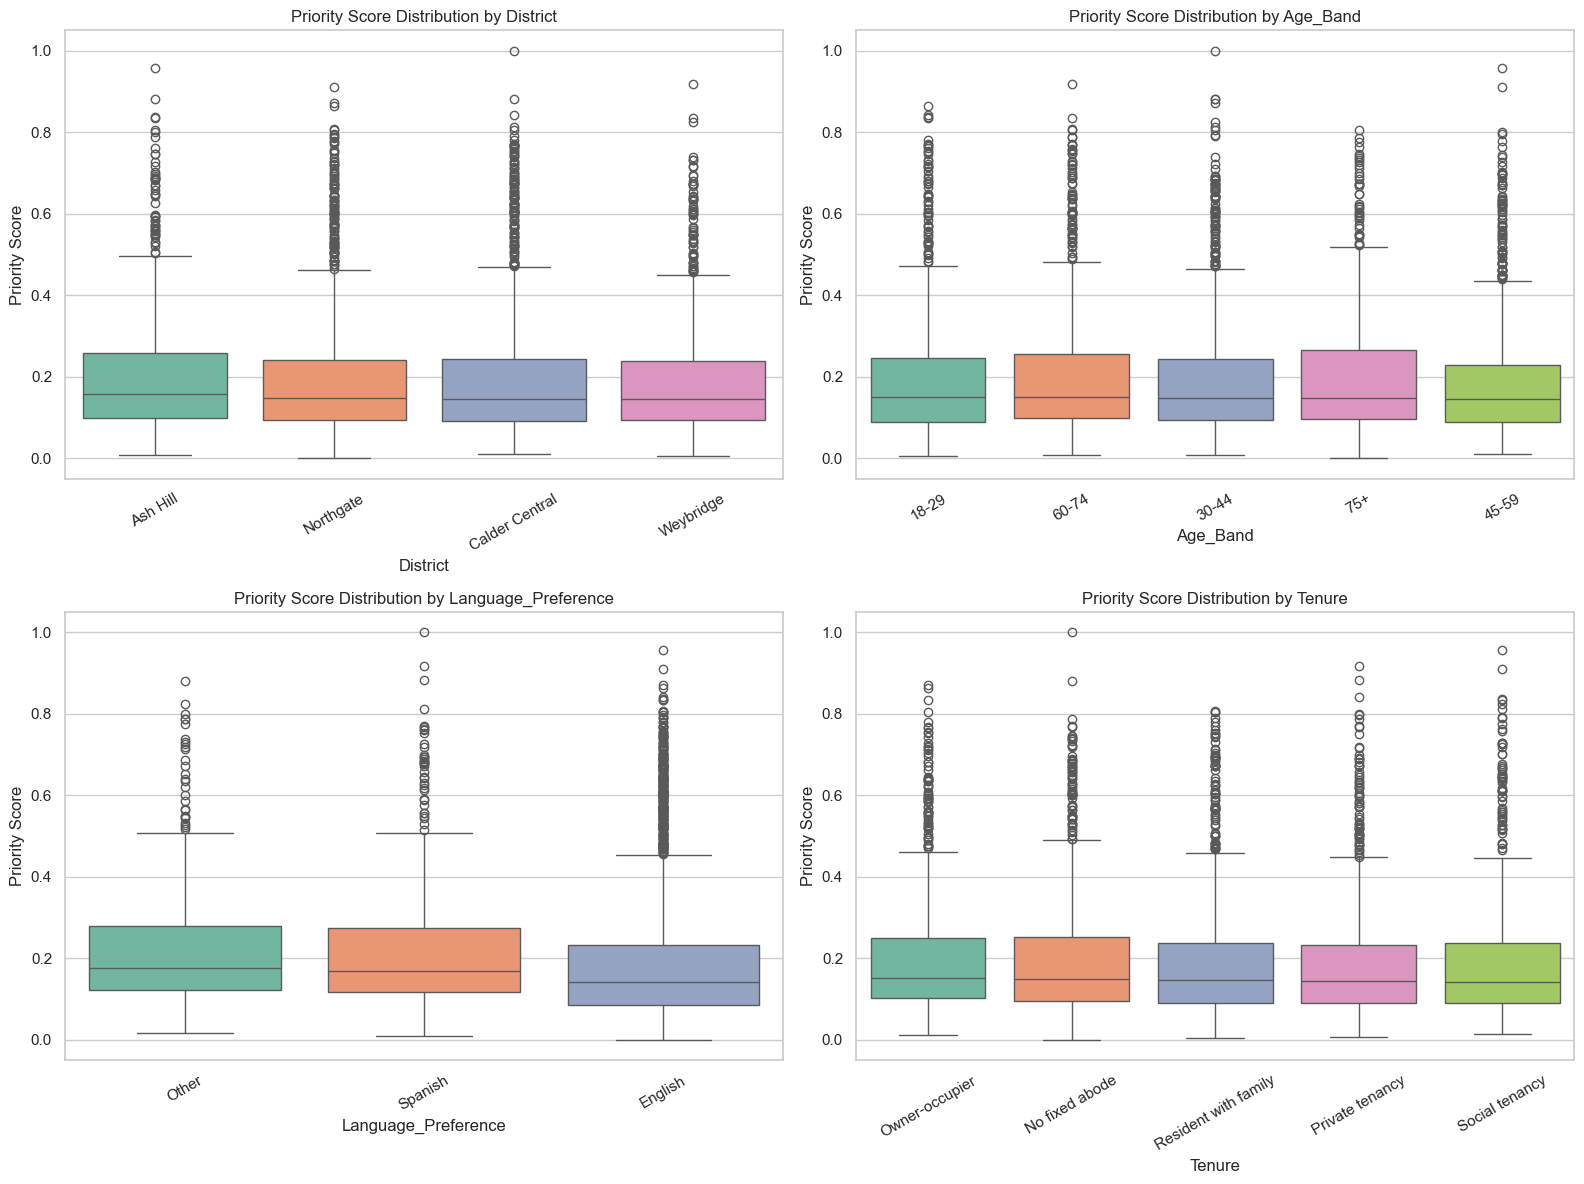

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, col in enumerate(demographics):
    ax = axes[idx // 2, idx % 2]
    # Sort categories by median score descending for visual clarity
    category_order = df_scored.groupby(col)['priority_score'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_scored, x=col, y='priority_score', ax=ax, order=category_order, palette='Set2')
    ax.set_title(f'Priority Score Distribution by {col.title()}')
    ax.set_ylabel('Priority Score')
    ax.set_xlabel(col.title())
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Step 4: Small-Sample Limitations

> [!WARNING]
> **Methodological Limitations & Small-Sample Warnings:**
> 1. **Top-20 Sample Size**: The final worklist contains only **20 cases**. With such a small sample size, statistical variance is extremely high.
> 2. **High Sensitivity to Single Cases**: A shift of just one or two cases in the Top 20 can alter a subgroup's top-20 percentage by 5.0% or 10.0%, causing large swings in representation ratios.
> 3. **Unstable Ratios for Small Groups**: For small population groups (e.g. language preference 'Other' at 9.83%), representation ratios are highly volatile. A single case selection can result in a massive ratio spike, while zero selections yields 0.0.
> 4. **No Proof of Discrimination**: Observed representation differences do **not** establish bias or discrimination in the model. Standard demographic disparities can arise from legitimate underlying factors in transaction behavior (e.g. higher historical adjustment rates or closure rates in certain sub-populations).
> 5. **Requirement for Defensible Audits**: Establishing a stronger statistical conclusion regarding model fairness would require evaluating larger historical samples (thousands of cases) and utilizing reliable, confirmed outcome labels (verified improper payments) rather than model priority scores.

## 6. Step 5: Governance Findings

Based on our post-hoc audit, we report the following observations using neutral, non-discriminatory terminology:

### Proportionality Overview:
* The Top 20 prioritized cases exhibit some **representation differences** compared to the overall client population.
* Due to the small-sample size, these differences represent **potential concerns** that warrant further investigation rather than definitive proof of algorithmic bias.

### Key Group Representation Findings:
1. **District Differences**:
   * **Ash Hill** is over-represented in the Top 20 with a **representation ratio of 1.90** (holding 30.0% of Top 20 spots vs. 15.79% of the population).
   * **Weybridge** is under-represented in the Top 20 with a **representation ratio of 0.64** (holding 15.0% of Top 20 spots vs. 23.40% of the population).
   * *Note*: Average priority scores across districts are highly uniform (~0.19 to ~0.21), suggesting the model does not score districts differently on average.

2. **Age Band Differences**:
   * **30-44** age band shows moderate over-representation with a **ratio of 1.32** (35.0% in Top 20 vs. 26.48% in population).
   * **75+** age band shows under-representation with a **ratio of 0.40** (5.0% in Top 20 vs. 12.40% in population).
   * *Note*: Average priority scores are highly stable across all age groups (~0.19 to ~0.20).

3. **Language Preference Differences**:
   * **English** preferring clients are under-represented with a **ratio of 0.83** (65.0% in Top 20 vs. 78.02% in population).
   * **Spanish** (ratio 1.65) and **Other** (ratio 1.53) preferring clients are over-represented. 
   * *Note*: Average priority scores show a slight observed difference (Spanish: 0.2216, Other: 0.2244, English: 0.1920). This represents a **potential concern** that **requires further investigation** on larger datasets.

4. **Housing Tenure Differences**:
   * **Social tenancy** clients are over-represented in the Top 20 with a **ratio of 1.44** (30.0% of Top 20 spots vs. 20.86% of the population).
   * **No fixed abode** clients are under-represented in the Top 20 with a **ratio of 0.49** (10.0% of Top 20 spots vs. 20.36% of the population).

### Limitations & Conclusions:
* There is **insufficient evidence to conclude bias** in the algorithm. The observed differences could correlate with legitimate transactional variance (such as higher rate of post-closure payments in Spanish/Other language preferences due to administrative hurdles). Further research with human auditors is required.

## 7. Step 6: Save Audit Report

We save the compiled fairness and governance metrics to `data/processed/fairness_report.csv`.

In [6]:
report_path = '../data/processed/fairness_report.csv'
os.makedirs(os.path.dirname(report_path), exist_ok=True)
df_report.to_csv(report_path, index=False)
print(f'Fairness report successfully written to {report_path}!')

Fairness report successfully written to ../data/processed/fairness_report.csv!


## 8. Step 8: Notebook Verification Checks

We run assertion checks to verify that the audit successfully covered all categories, Top-20 counts, and that model features contain no demographic parameters.

In [7]:
print('--- RUNNING AUDIT INTEGRITY CHECKS ---')
# Verify 4 demographic fields in report
fields_audited = set(df_report['demographic_field'])
print(f"1. All 4 demographic categories audited: {fields_audited == set(demographics)}")

# Verify Top 20 counts
total_top20_audited = df_report[df_report['demographic_field'] == 'district']['top20_count'].sum()
print(f"2. Top 20 cases summed check: {total_top20_audited == 20}")

# Verify representation calculations
sample_row = df_report.iloc[0]
expected_ratio = sample_row['top20_percentage'] / sample_row['population_percentage']
diff_ratio = abs(sample_row['representation_ratio'] - expected_ratio)
print(f"3. Representation ratio calculation correct: {diff_ratio < 0.0001}")

# Verify no demographics are used for predictions
model_inputs_path = '../src/model.py'
with open(model_inputs_path, 'r') as f:
    model_code = f.read()
demographics_excluded = all(f"{col}" not in model_code.split('numeric_features =')[1].split(']')[0] for col in demographics)
print(f"4. Demographics confirmed excluded from model predictive list: {demographics_excluded}")

--- RUNNING AUDIT INTEGRITY CHECKS ---
1. All 4 demographic categories audited: True
2. Top 20 cases summed check: True
3. Representation ratio calculation correct: True
4. Demographics confirmed excluded from model predictive list: True


## Fairness Summary

### Summary of Observed Representation Patterns
The post-hoc fairness and governance audit reveals that while average priority scores are relatively uniform across most subgroups, some **observed representation differences** are present within the Top 20 investigation worklist. Specifically, clients from Ash Hill district, Spanish/Other language preferences, and Social tenancy housing situations show higher relative representation in the Top 20, whereas Weybridge, 75+ age bands, and No fixed abode clients show lower representation.

### Limitations & Context
Due to the small sample size of the Top 20, these ratios are highly sensitive to small case variations and do **not** provide evidence of model bias. Standard disparities can reflect underlying structural risk profiles rather than algorithmic discrimination. Further validation requires evaluating larger datasets and incorporating verified ground-truth labels.

### Investigation Tool Boundaries
This algorithm is designed solely as an **investigation-prioritization tool** to help allocate limited caseworker review capacity. The priority scores do **not** constitute a determination of fraud or benefit adjustments. All final case evaluations, investigations, and benefit decisions remain exclusively within the purview of **human investigators**.